In [50]:
import os, torch, gc
import numpy as np
import pandas as pd
from torch.nn.functional import sigmoid
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import transforms
from sklearn.model_selection import train_test_split

from src.Models import (
    CancerClassifierResNet18_V1,
    CancerClassifierResNet50_V1,
    CancerClassifierCoaTLiteTiny,
    model_b0,
    HistopathologyDataset
)

from tqdm import tqdm

In [51]:
def set_seed(seed=42):
    import random
    import numpy as np
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

set_seed(777)
torch.backends.cudnn.benchmark = True
torch.cuda.empty_cache()
gc.collect()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Exception ignored in: <function tqdm.__del__ at 0x7e4b563d1090>
Traceback (most recent call last):
  File "/media/lak_05/Windows-SSD/ML/PathoDetect/.venv/lib/python3.10/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/media/lak_05/Windows-SSD/ML/PathoDetect/.venv/lib/python3.10/site-packages/tqdm/notebook.py", line 279, in close
    self.disp(bar_style='danger', check_delay=False)
AttributeError: 'tqdm_notebook' object has no attribute 'disp'


### Checking for Class Imbalance

In [52]:
base_path = "/media/lak_05/Windows-SSD/ML/PathoDetect/Data"
train_csv = os.path.join(base_path, "train_labels.csv")
train_img_dir = os.path.join(base_path, "train")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

full_dataset = HistopathologyDataset(train_csv, train_img_dir, transform)

train_idx, val_idx = train_test_split(
    list(range(len(full_dataset))),
    test_size=0.12,
    stratify=full_dataset.labels_df['label'],
    random_state=777
)

val_dataset = Subset(full_dataset, val_idx)
val_loader = DataLoader(val_dataset, batch_size=56, shuffle=False, num_workers=4, pin_memory=True)


### Visualizing a few images

In [53]:
model_paths = {
    "ResNet18":      "/media/lak_05/Windows-SSD/ML/PathoDetect/Final_Models/ResNet18.pth",
    "ResNet50":      "/media/lak_05/Windows-SSD/ML/PathoDetect/Final_Models/ResNet50.pth",
    "CoaTLite":      "/media/lak_05/Windows-SSD/ML/PathoDetect/Final_Models/CoaTLite.pth",
    "EfficientNetB0":"/media/lak_05/Windows-SSD/ML/PathoDetect/Final_Models/EfficientNetB0.pth"
}

thresholds = {
    "ResNet18": 0.33,
    "ResNet50": 0.41,
    "CoaTLite": 0.37,
    "EfficientNetB0": 0.39
}

weights = {
    "ResNet18": 0.9672,
    "ResNet50": 0.9668,
    "CoaTLite": 0.9738,
    "EfficientNetB0": 0.968
}
total_weight = sum(weights.values())
norm_weights = {k: v / total_weight for k, v in weights.items()}

models = {}

# Load each model
with torch.no_grad():
    models["ResNet18"] = CancerClassifierResNet18_V1().to(device)
    checkpoint = torch.load(model_paths["ResNet18"], map_location=device, weights_only=False)
    models["ResNet18"].load_state_dict(checkpoint["model_state"])
    models["ResNet18"].eval()

    models["ResNet50"] = CancerClassifierResNet50_V1().to(device)
    checkpoint = torch.load(model_paths["ResNet50"], map_location=device, weights_only=False)
    models["ResNet50"].load_state_dict(checkpoint["model_state"])
    models["ResNet50"].eval()

    models["CoaTLite"] = CancerClassifierCoaTLiteTiny().to(device)
    checkpoint = torch.load(model_paths["CoaTLite"], map_location=device, weights_only=False)
    models["CoaTLite"].load_state_dict(checkpoint["model_state"])
    models["CoaTLite"].eval()

    models["EfficientNetB0"] = model_b0().to(device)
    checkpoint = torch.load(model_paths["EfficientNetB0"], map_location=device, weights_only=False)
    models["EfficientNetB0"].load_state_dict(checkpoint["model_state"])
    models["EfficientNetB0"].eval()


- 1 - Cancer 
- 2 - Not Cancer

In [54]:
all_preds = []
all_labels = []
ensemble_confidences = []

with torch.no_grad():
    for inputs, labels in tqdm(val_loader, desc="🔍 Validating", unit="batch"):
        inputs = inputs.to(device)
        labels = labels.to(device)

        individual_preds = {}
        weighted_outputs = 0

        for name, model in models.items():
            prob = sigmoid(model(inputs)).squeeze()
            pred = (prob >= thresholds[name]).float()
            weighted_outputs += pred * norm_weights[name]

        final_pred = (weighted_outputs >= 0.5).int()
        all_preds.extend(final_pred.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        ensemble_confidences.extend(weighted_outputs.cpu().numpy())


🔍 Validating: 100%|██████████| 472/472 [02:25<00:00,  3.25batch/s]


In [55]:
f1 = f1_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
roc = roc_auc_score(all_labels, all_preds)

print("Ensemble Metrics on Validation Set:")
print(f"F1 Score:     {f1:.4f}")
print(f"Precision:    {precision:.4f}")
print(f"Recall:       {recall:.4f}")
print(f"ROC AUC:      {roc:.4f}")


✅ Ensemble Metrics on Validation Set:
F1 Score:     0.9715
Precision:    0.9644
Recall:       0.9786
ROC AUC:      0.9770


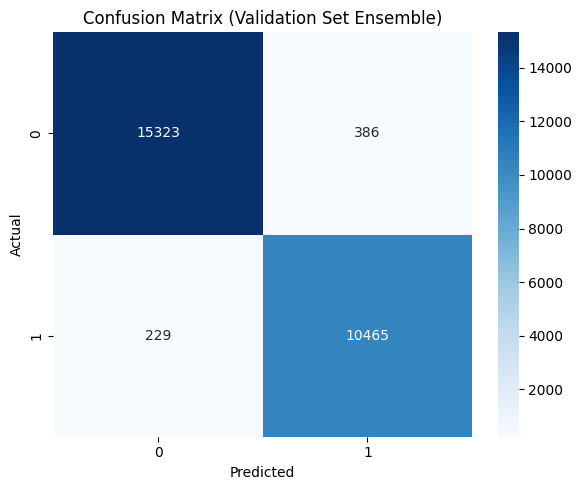

In [56]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Validation Set Ensemble)")
plt.tight_layout()
plt.show()


In [57]:
df = pd.DataFrame({
    "True Label": all_labels,
    "Predicted Label": all_preds,
    "Ensemble Confidence": ensemble_confidences
})
df.to_csv("ensemble_validation_results.csv", index=False)


In [58]:
from PIL import Image
import matplotlib.pyplot as plt

# Assuming you have this:
# val_loader = DataLoader(val_dataset, ...)
# which is a Subset of HistopathologyDataset
# So we must recover indices to get filenames

all_preds = []
all_labels = []
ensemble_confidences = []
image_paths = []

# Recover underlying dataset
val_indices = val_loader.dataset.indices  # since it's a Subset
full_dataset = val_loader.dataset.dataset  # the full HistopathologyDataset

with torch.no_grad():
    for batch_idx, (inputs, labels) in enumerate(tqdm(val_loader, desc="🔍 Validating")):
        inputs = inputs.to(device)
        labels = labels.to(device)

        batch_start = batch_idx * val_loader.batch_size
        batch_indices = val_indices[batch_start: batch_start + len(inputs)]

        for i, img_idx in enumerate(batch_indices):
            image_paths.append(full_dataset.image_paths[img_idx])  # absolute image path

        preds, probs = [], []

        for model, t, w in zip(models, thresh, norm_weights):
            prob = sigmoid(model(inputs)).squeeze()
            preds.append((prob >= t).float())
            probs.append(prob)

        weighted_sum = sum([preds[i] * norm_weights[i] for i in range(4)])
        final_pred = (weighted_sum >= 0.5).int()

        all_preds.extend(final_pred.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        ensemble_confidences.extend(weighted_sum.cpu().numpy())


🔍 Validating:   0%|          | 0/472 [00:00<?, ?it/s]


AttributeError: 'HistopathologyDataset' object has no attribute 'image_paths'